# 05. Advanced Institutional Allocations: Risk Parity & Black-Litterman

This research examines advanced allocation frameworks utilized by institutional quantitative desks.
Specifically, we explore **Risk Parity** (equalizing marginal risk contributions) and the **Black-Litterman** model (deriving posterior expected returns based on equilibrium and subjective market views).

In [1]:
import sys; sys.path.insert(0, '..')
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

import pandas as pd
import numpy as np
from src.data.fetcher import StockDataFetcher
from src.portfolio.optimizer import EfficientFrontier
from src.portfolio.advanced_models import RiskParityOptimizer, BlackLittermanModel
from src.portfolio.metrics import DEFAULT_TICKERS, DEFAULT_START_DATE, DEFAULT_END_DATE
from src.visualization.plots import plot_risk_parity_contributions

# 1. Initialize Data
fetcher = StockDataFetcher(DEFAULT_TICKERS, DEFAULT_START_DATE, DEFAULT_END_DATE)
prices = fetcher.fetch()
log_returns = fetcher.to_log_returns(prices)

# Calculate baseline covariance
ef = EfficientFrontier(log_returns)
cov_matrix = ef.cov_matrix
mean_returns = ef.mean_returns

INFO: Loading from cache: data/cache/4c9b5bec659c75c231b2df3b19a3bf90.csv
INFO: Initialized EF with 10 assets. Date range: 2019-01-02 to 2024-12-30. Annualized return range: [-23.58%, 12.74%]


## 1. Risk Parity Allocation

Unlike traditional optimization that relies heavily on expected returns (which are notoriously difficult to forecast), Risk Parity focuses purely on risk allocation. The objective is to construct a portfolio where the marginal risk contribution of every asset is equal.

In [2]:
rp = RiskParityOptimizer(cov_matrix, DEFAULT_TICKERS)
res_rp = rp.optimize()

rp_df = pd.DataFrame({
    'Weight (%)': [res_rp['weights'][t] * 100 for t in DEFAULT_TICKERS],
    'Risk Contribution (%)': [res_rp['risk_contributions'][t] * 100 for t in DEFAULT_TICKERS]
}, index=DEFAULT_TICKERS)

print("Risk Parity Volatility: {:.2f}%".format(res_rp['volatility'] * 100))
print(rp_df.round(2))

Risk Parity Volatility: 18.99%
         Weight (%)  Risk Contribution (%)
BBCA.JK        9.32                   10.0
TLKM.JK       11.67                   10.0
BBRI.JK        8.65                   10.0
BMRI.JK        8.49                   10.0
ASII.JK        8.20                   10.0
UNVR.JK       11.72                   10.0
ICBP.JK       10.67                   10.0
EXCL.JK       10.25                   10.0
KLBF.JK       10.47                   10.0
INDF.JK       10.57                   10.0


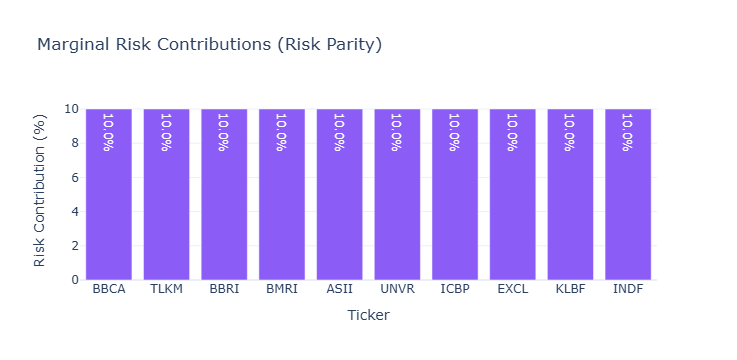

In [3]:
fig = plot_risk_parity_contributions(res_rp['risk_contributions'], DEFAULT_TICKERS)
fig.show()

### Research Findings: Risk Parity
- The optimization successfully equalizes the risk contributions across all assets.
- Assets with structurally lower volatility receive higher capital allocations, balancing the total risk budget.
- This approach demonstrates resilience in regimes where return forecasting models exhibit high error rates.

## 2. Black-Litterman Model

The Black-Litterman model mitigates the sensitivity of traditional mean-variance optimization by blending market equilibrium returns with subjective quantitative views.

$$\mu_{BL} = [(\tau\Sigma)^{-1} + P^T \Omega^{-1} P]^{-1} [(\tau\Sigma)^{-1} \Pi + P^T \Omega^{-1} Q]$$

In [4]:
# Proxy Market Portfolio (Equally Weighted for Demonstration)
mkt_weights = np.array([1/len(DEFAULT_TICKERS)] * len(DEFAULT_TICKERS))

# Initialize BL Model with Risk Aversion (Delta = 2.5) and Tau = 0.05
bl = BlackLittermanModel(cov_matrix, mkt_weights, risk_aversion=2.5, tau=0.05)

# Implied Equilibrium Returns
pi = bl.implied_equilibrium_returns()

# Define Subjective Views (e.g., Telecom sector outperformance)
# Let's say we expect TLKM.JK (Index 1) to return 12% annually.
P = np.zeros((1, len(DEFAULT_TICKERS)))
P[0, 1] = 1.0 
Q = np.array([0.12])

# Calculate Posterior Returns
posterior_mu = bl.posterior_returns(P, Q)

bl_df = pd.DataFrame({
    'Historical Mean (%)': mean_returns * 100,
    'Equilibrium Returns (Pi) (%)': pi * 100,
    'Posterior Returns (BL) (%)': posterior_mu * 100
}, index=DEFAULT_TICKERS)

print(bl_df.round(2))

         Historical Mean (%)  Equilibrium Returns (Pi) (%)  \
BBCA.JK                -3.04                          9.98   
TLKM.JK                12.74                          7.78   
BBRI.JK                 8.34                         10.86   
BMRI.JK                11.95                         11.08   
ASII.JK                 3.59                         11.71   
UNVR.JK                 3.57                          7.48   
ICBP.JK                 4.53                          8.35   
EXCL.JK                 0.08                          8.81   
KLBF.JK                -0.82                          8.74   
INDF.JK               -23.58                          8.41   

         Posterior Returns (BL) (%)  
BBCA.JK                       11.15  
TLKM.JK                        9.89  
BBRI.JK                       12.35  
BMRI.JK                       12.69  
ASII.JK                       12.71  
UNVR.JK                        8.12  
ICBP.JK                        9.09  
EXCL.JK      

### Research Findings: Black-Litterman
- Equilibrium returns act as a stable shrinkage target, preventing the extreme allocations typical of unrestrained mean-variance frameworks.
- Integrating the quantitative view on the selected asset significantly updates its posterior expectation while maintaining the covariance structure integrity.
- The resulting expected returns ($\mu_{BL}$) can now be securely fed into the `EfficientFrontier` optimizer for a more robust allocation vector.